
Training model for Linear Equation
Linear Equation Test MSE: 0.0000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


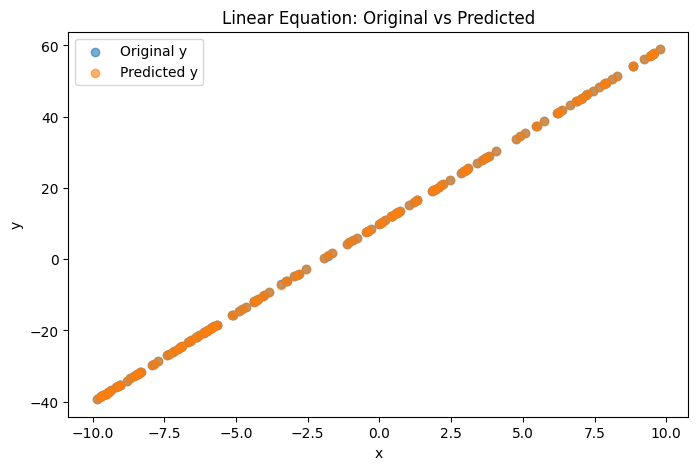

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted value: 44.999077

Training model for Quadratic Equation
Quadratic Equation Test MSE: 0.3599
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


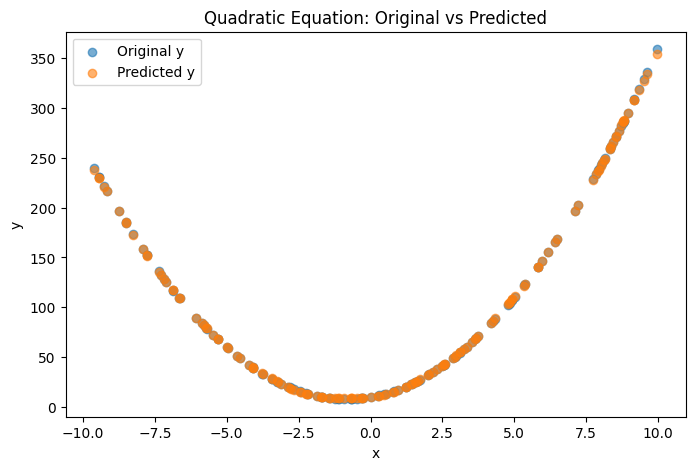

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted value: 191.65489

Training model for Cubic Equation
Cubic Equation Test MSE: 145.3731
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


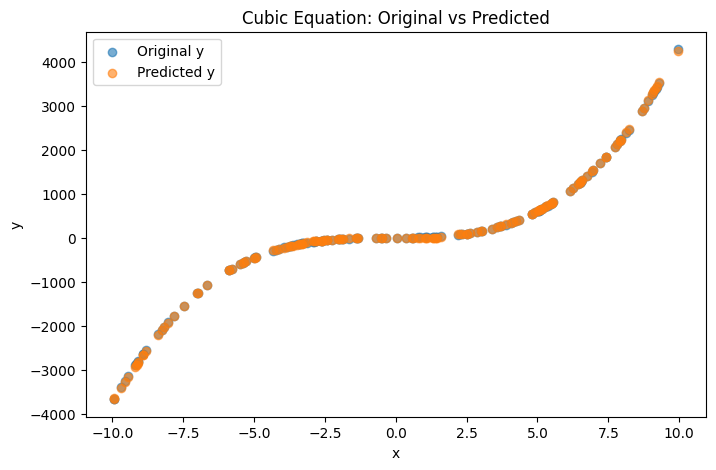

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted value: 1565.2313


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


# Equations

def equation_linear(x):
    return 5*x + 10

def equation_quadratic(x):
    return 3*x**2 + 5*x + 10

def equation_cubic(x):
    return 4*x**3 + 3*x**2 + 5*x + 10



# Data Generation

def data_gen(func, n=1000):
    x = np.random.uniform(-10, 10, n).astype(np.float32)
    y = func(x).astype(np.float32)
    return x.reshape(-1,1), y



# Train,Validation,Test Split

def split(x, y, train_ratio=0.7, val_ratio=0.15):
    n = len(x)
    train_n = int(n * train_ratio)
    val_n = int(n * val_ratio)

    trainx, trainy = x[:train_n], y[:train_n]
    valx, valy = x[train_n:train_n+val_n], y[train_n:train_n+val_n]
    testx, testy = x[train_n+val_n:], y[train_n+val_n:]

    return trainx, trainy, valx, valy, testx, testy



# Model Generator (Adjustable Depth)

def model_gen(hidden_units=64, layers=2):
    inputs = Input((1,))
    x = inputs

    for i in range(layers):
        x = Dense(hidden_units, activation='relu')(x)

    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.01), loss='mse')
    return model


    # Predict a single value
    x_new = np.array([[7]], dtype=np.float32)   # shape must be (1,1)
    prediction = model.predict(x_new)

    print("Predicted value:", prediction[0][0])
# Plot Function

def show(testX, testY, y_pred, title):
    plt.figure(figsize=(8,5))
    plt.scatter(testX, testY, label='Original y', alpha=0.6)
    plt.scatter(testX, y_pred, label='Predicted y', alpha=0.6)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()



# Training Procedure

def train_model(func, name, layers):
    print(f"\nTraining model for {name}")

    x, y = data_gen(func)
    trainx, trainy, valx, valy, testx, testy = split(x, y)

    model = model_gen(hidden_units=64, layers=layers)

    history = model.fit(trainx, trainy,
                        validation_data=(valx, valy),
                        epochs=60,
                        batch_size=32,
                        verbose=0)

    test_loss = model.evaluate(testx, testy, verbose=0)
    print(f"{name} Test MSE: {test_loss:.4f}")

    y_pred = model.predict(testx)
    show(testx, testy, y_pred, f"{name}: Original vs Predicted")

    # Predict a single value
    x_new = np.array([[7]], dtype=np.float32)   # shape must be (1,1)
    prediction = model.predict(x_new)

    print("Predicted value:", prediction[0][0])

    return test_loss


if __name__ == "__main__":

    # Linear
    train_model(equation_linear, "Linear Equation", layers=1)

    # Quadratic
    train_model(equation_quadratic, "Quadratic Equation", layers=2)

    # Cubic
    train_model(equation_cubic, "Cubic Equation", layers=3)


In [10]:
    # print(f"Test MSE: {test_loss:.4f}")
    # # Plot training & validation loss
    # plt.figure(figsize=(8,5))
    # plt.plot(history.history['loss'], label='Training Loss')
    # plt.plot(history.history['val_loss'], label='Validation Loss')
    # plt.title('Training and Validation Loss')
    # plt.xlabel('Epoch')
    # plt.ylabel('MSE')
    # plt.legend()
    # plt.show()